In [1]:
import pandas as pd

df = pd.read_csv('/content/customer_data.csv')
df


,CustomerID,Age,Gender,Annual_Income,Spending_Score,Num_Transactions
0,1001,56,Female,48138,27,21
1,1002,46,Male,61105,49,21
2,1003,32,Female,43213,77,18
3,1004,60,Male,61655,33,21
4,1005,25,Male,65683,98,20
...,...,...,...,...,...,...
195,1196,49,Female,45766,10,20
196,1197,49,Male,54432,67,21
197,1198,41,Female,33539,18,21
198,1199,58,Female,55113,86,23


In [2]:
print(df.head())

   CustomerID  Age  Gender  Annual_Income  Spending_Score  Num_Transactions
0        1001   56  Female          48138              27                21
1        1002   46    Male          61105              49                21
2        1003   32  Female          43213              77                18
3        1004   60    Male          61655              33                21
4        1005   25    Male          65683              98                20


In [3]:
print(df.describe())


        CustomerID         Age  Annual_Income  Spending_Score  \
count   200.000000  200.000000     200.000000      200.000000   
mean   1100.500000   41.570000   52513.590000       50.700000   
std      57.879185   13.715527   14800.207646       29.903026   
min    1001.000000   18.000000   18649.000000        1.000000   
25%    1050.750000   30.000000   43027.750000       25.000000   
50%    1100.500000   42.000000   51909.500000       51.500000   
75%    1150.250000   54.000000   63349.500000       78.000000   
max    1200.000000   64.000000   85835.000000       99.000000   

       Num_Transactions  
count        200.000000  
mean          20.025000  
std            4.521793  
min            9.000000  
25%           17.000000  
50%           20.000000  
75%           23.000000  
max           32.000000  


In [11]:
# Mean, Median, Mode


print("Mean Income:", df['Annual_Income'].mean())
print("Median Income:", df['Annual_Income'].median())
print("Mode Income:", df['Annual_Income'].mode()[0])


Mean Income: 52513.59
Median Income: 51909.5
Mode Income: 18649


In [12]:
# Standard deviation, variance, range


print("Std Dev:", df['Spending_Score'].std())
print("Variance:", df['Spending_Score'].var())
print("Range:", df['Spending_Score'].max() - df['Spending_Score'].min())


Std Dev: 29.903025846456913
Variance: 894.1909547738702
Range: 98


In [13]:
print("Skewness:", df['Annual_Income'].skew())
print("Kurtosis:", df['Annual_Income'].kurt())


Skewness: -0.125910646374417
Kurtosis: -0.43796954066292226


In [14]:
df.corr(numeric_only=True)


,CustomerID,Age,Annual_Income,Spending_Score,Num_Transactions
CustomerID,1.000000,0.059256,-0.007375,-0.069845,-0.005635
Age,0.059256,1.000000,0.074185,0.002343,-0.013924
Annual_Income,-0.007375,0.074185,1.000000,-0.018195,-0.033015
Spending_Score,-0.069845,0.002343,-0.018195,1.000000,0.044578
Num_Transactions,-0.005635,-0.013924,-0.033015,0.044578,1.000000


In [15]:
# Count of gender

df['Gender'].value_counts()

# Age group distribution

df['Age_Group'] = pd.cut(df['Age'], bins=[17, 25, 35, 50, 65], labels=['18–25', '26–35', '36–50', '51–65'])
df['Age_Group'].value_counts()


,count
Age_Group,
36–50,64
51–65,63
26–35,38
18–25,35


In [16]:
# Average spending score by gender

df.groupby('Gender')['Spending_Score'].mean()

# Mean income by age group

df.groupby('Age_Group')['Annual_Income'].mean()


<ipython-input-16-bbf7e380cd5f>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Annual_Income'].mean()


,Annual_Income
Age_Group,
18–25,49619.885714
26–35,49268.315789
36–50,56426.875000
51–65,52103.269841


In [17]:
from scipy.stats import zscore

df['Income_Z'] = zscore(df['Annual_Income'])
outliers = df[df['Income_Z'].abs() > 3]
print("Outliers in Annual Income:\n", outliers)


Outliers in Annual Income:
 Empty DataFrame
Columns: [CustomerID, Age, Gender, Annual_Income, Spending_Score, Num_Transactions, Age_Group, Income_Z]
Index: []


In [18]:
# Spend per transaction

df['Spend_per_Transaction'] = df['Annual_Income'] / df['Num_Transactions']


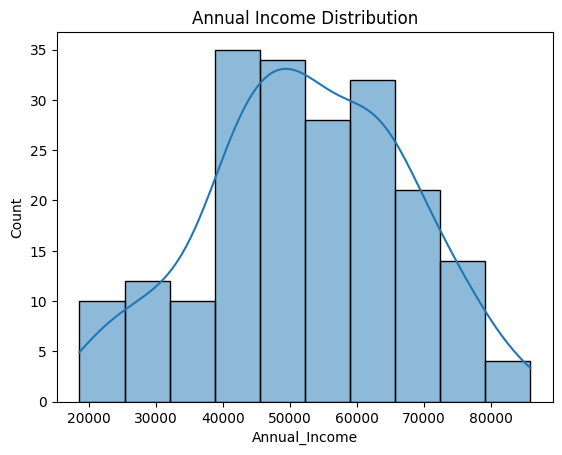

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Annual_Income'], kde=True)
plt.title("Annual Income Distribution")
plt.show()


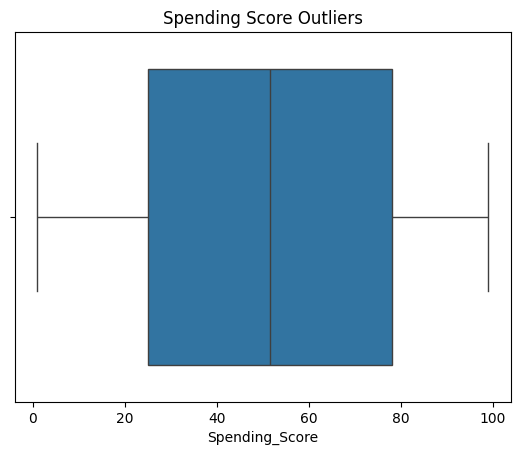

In [5]:
sns.boxplot(x='Spending_Score', data=df)
plt.title("Spending Score Outliers")
plt.show()


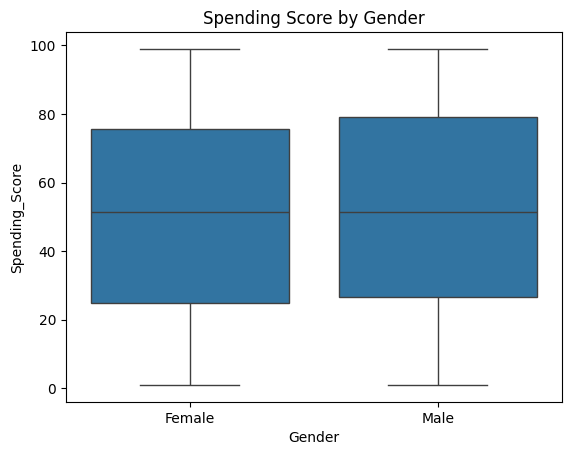

In [10]:
sns.boxplot(x='Gender', y='Spending_Score', data=df)
plt.title("Spending Score by Gender")
plt.show()
